# Assignment 1: Student Performance Prediction## Linear Regression — Exam Score Prediction**Dataset:** Student Habits & Performance Dataset (1000 students, 16 columns)**Target:** `exam_score`**Algorithm:** Linear Regression (Simple + Multiple)**Evaluation:** MAE, MSE, RMSE, R² Score

---## Step 1: Import Libraries

In [32]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


---## Step 2: Load Dataset & Initial Inspection

In [33]:
# Load the dataset
df = pd.read_csv('student_habits_performance.csv')

# Basic inspection
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 16)

First 5 rows:


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [34]:
# Dataset info — datatypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [35]:
# Statistical summary of numeric columns
df.describe().round(2)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.50,3.55,2.51,1.82,84.13,6.47,3.04,5.44,69.60
std,2.31,1.47,1.17,1.08,9.40,1.23,2.03,2.85,16.89
min,17.00,0.00,0.00,0.00,56.00,3.20,0.00,1.00,18.40
25%,18.75,2.60,1.70,1.00,78.00,5.60,1.00,3.00,58.48
50%,20.00,3.50,2.50,1.80,84.40,6.50,3.00,5.00,70.50
75%,23.00,4.50,3.30,2.52,91.02,7.30,5.00,8.00,81.32
max,24.00,8.30,7.20,5.40,100.00,10.00,6.00,10.00,100.00


In [36]:
# Check missing values
print("Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})[missing > 0]

Missing Values per Column:


,Missing_Count,Missing_%
parental_education_level,91,9.1


In [37]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Unique values in categorical columns
print("\nUnique values in categorical columns:")
for col in ['gender','part_time_job','diet_quality','parental_education_level',
            'internet_quality','extracurricular_participation']:
    print(f"  {col}: {df[col].unique()}")

Duplicate rows: 0

Unique values in categorical columns:
  gender: ['Female' 'Male' 'Other']
  part_time_job: ['No' 'Yes']
  diet_quality: ['Fair' 'Good' 'Poor']
  parental_education_level: ['Master' 'High School' 'Bachelor' nan]
  internet_quality: ['Average' 'Poor' 'Good']
  extracurricular_participation: ['Yes' 'No']


---## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Target Variable — Exam Score Distribution

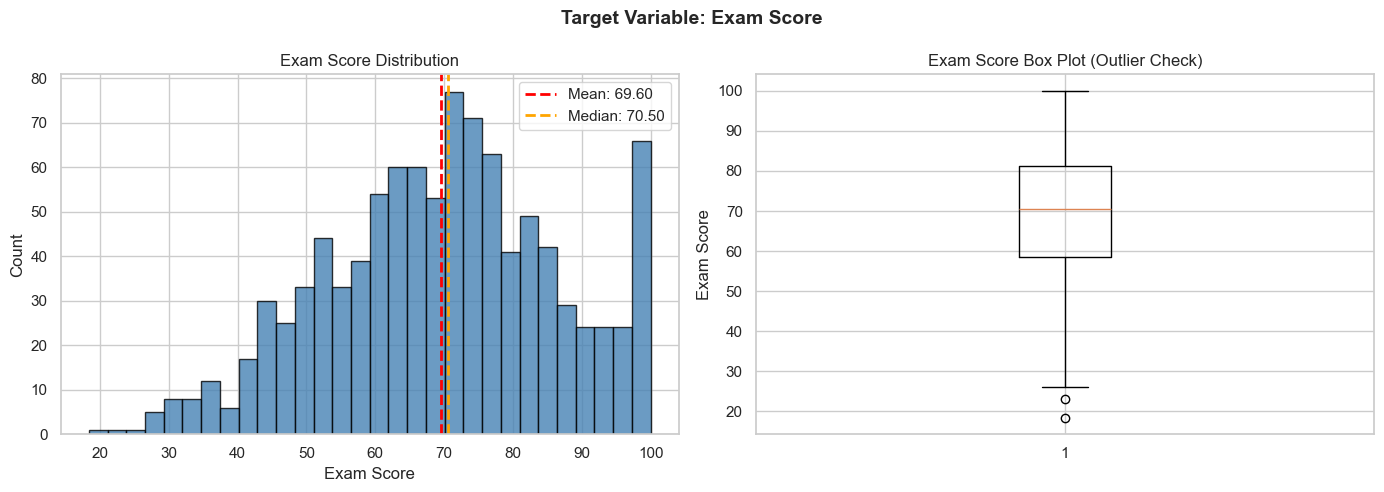

Min Score   : 18.4
Max Score   : 100.0
Mean Score  : 69.60
Median Score: 70.50
Std Dev     : 16.89


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['exam_score'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['exam_score'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['exam_score'].mean():.2f}")
axes[0].axvline(df['exam_score'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median: {df['exam_score'].median():.2f}")
axes[0].set_title('Exam Score Distribution')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
axes[1].boxplot(df['exam_score'], vert=True)
axes[1].set_title('Exam Score Box Plot (Outlier Check)')
axes[1].set_ylabel('Exam Score')

plt.suptitle('Target Variable: Exam Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Min Score   : {df['exam_score'].min()}")
print(f"Max Score   : {df['exam_score'].max()}")
print(f"Mean Score  : {df['exam_score'].mean():.2f}")
print(f"Median Score: {df['exam_score'].median():.2f}")
print(f"Std Dev     : {df['exam_score'].std():.2f}")

### 3.2 Numeric Features vs Exam Score (Scatter Plots)

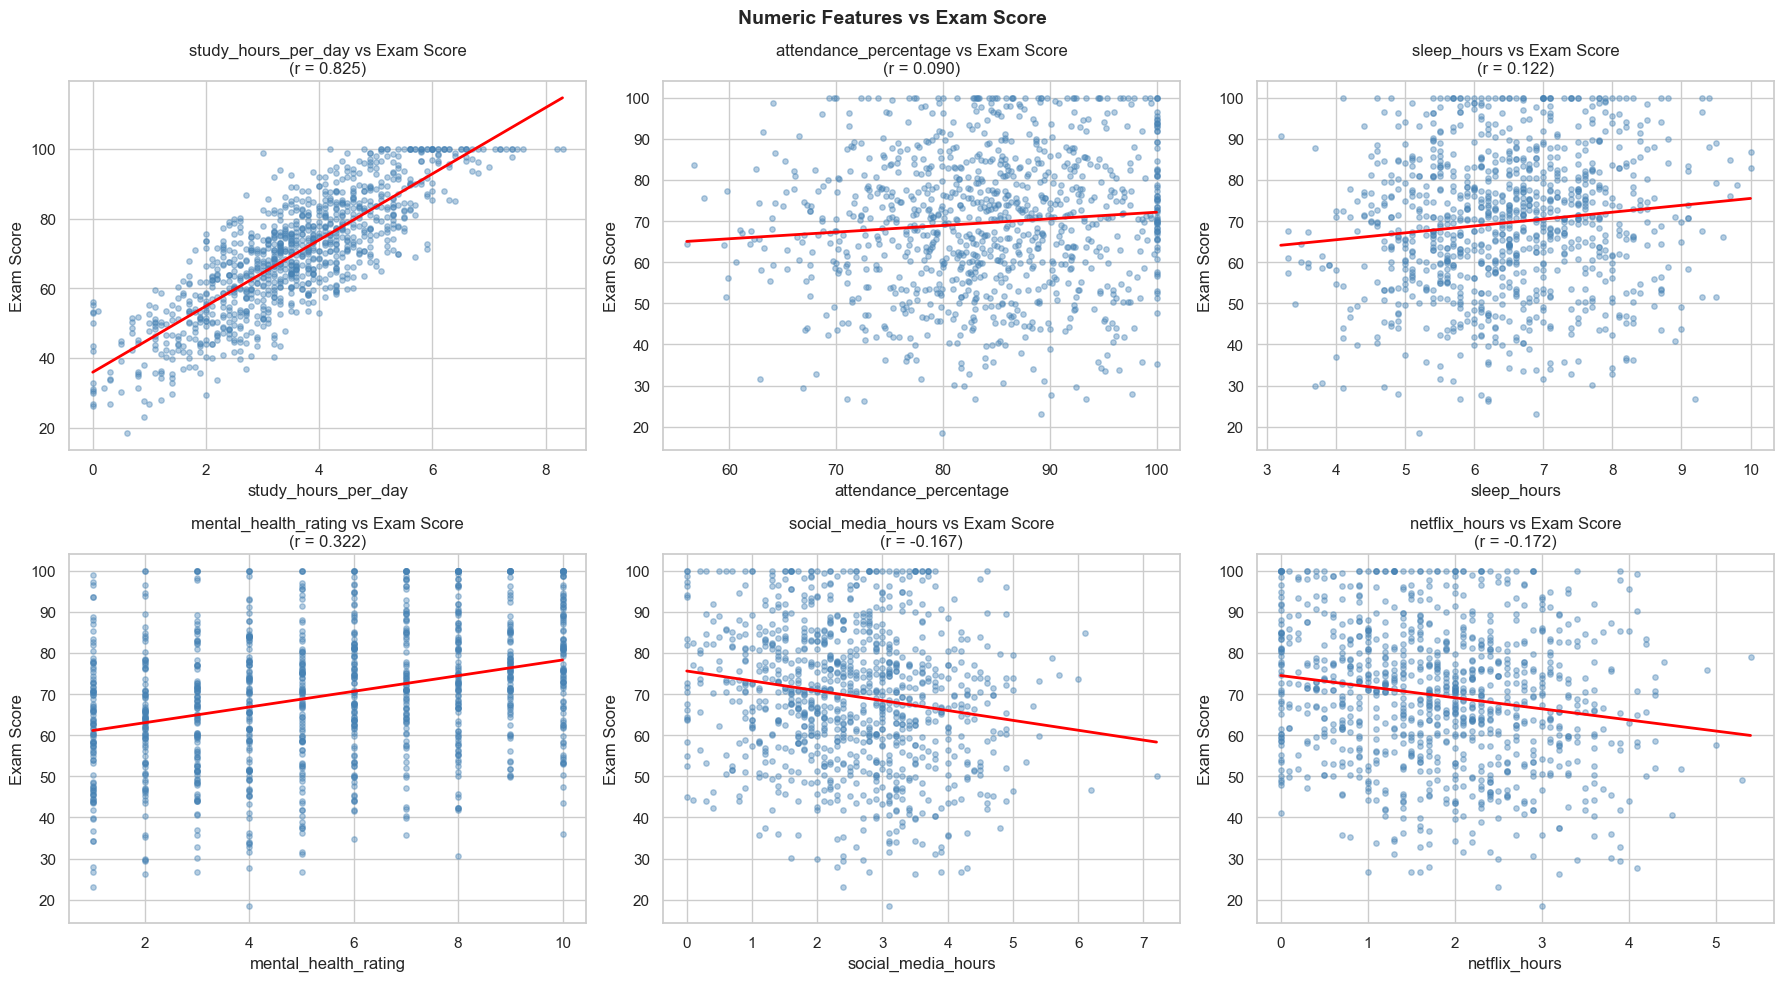

In [39]:
numeric_features = ['study_hours_per_day', 'attendance_percentage',
                    'sleep_hours', 'mental_health_rating',
                    'social_media_hours', 'netflix_hours']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].scatter(df[col], df['exam_score'], alpha=0.4, color='steelblue', s=15)
    # Trend line
    m, b = np.polyfit(df[col], df['exam_score'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line+b, color='red', linewidth=2)
    corr = df[col].corr(df['exam_score'])
    axes[i].set_title(f'{col} vs Exam Score\n(r = {corr:.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Exam Score')

plt.suptitle('Numeric Features vs Exam Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Categorical Features vs Exam Score

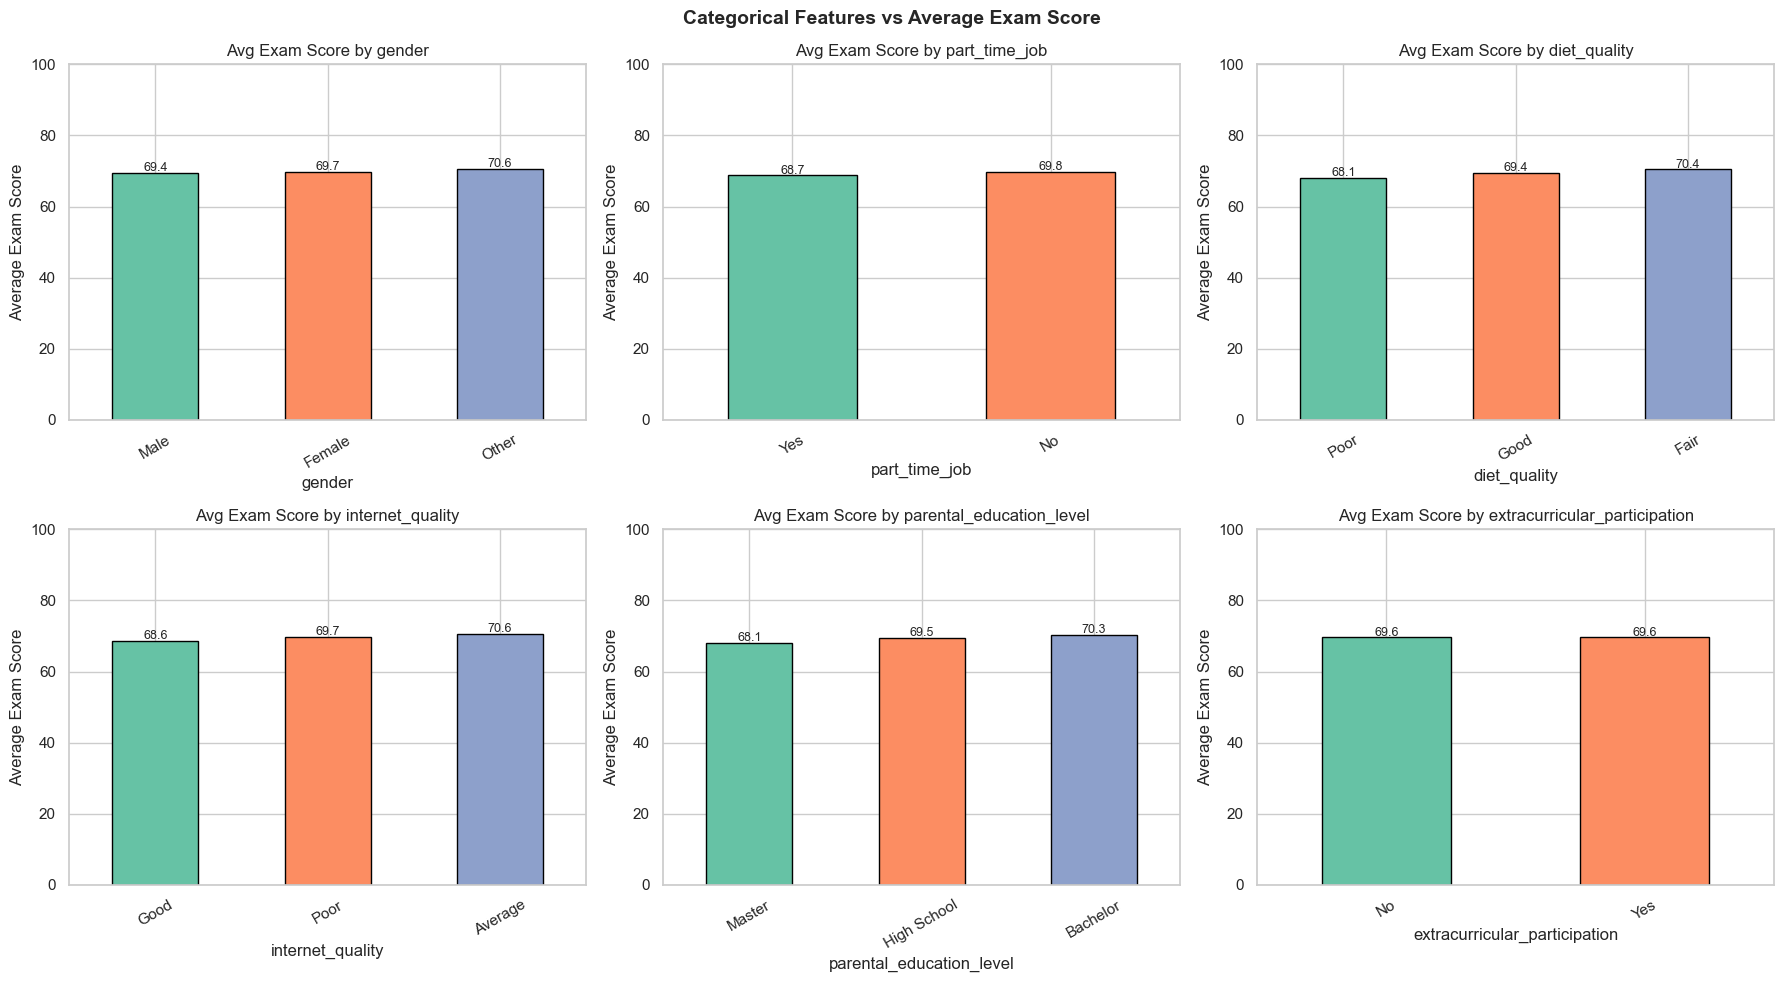

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cat_features = ['gender','part_time_job','diet_quality',
                'internet_quality','parental_education_level',
                'extracurricular_participation']

for ax, col in zip(axes.flatten(), cat_features):
    temp = df.dropna(subset=[col])
    temp.groupby(col)['exam_score'].mean().sort_values().plot(
        kind='bar', ax=ax, color=sns.color_palette('Set2'), edgecolor='black', rot=30)
    ax.set_title(f'Avg Exam Score by {col}')
    ax.set_ylabel('Average Exam Score')
    ax.set_ylim(0, 100)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x()+p.get_width()/2, p.get_height()+0.5),
                    ha='center', fontsize=9)

plt.suptitle('Categorical Features vs Average Exam Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

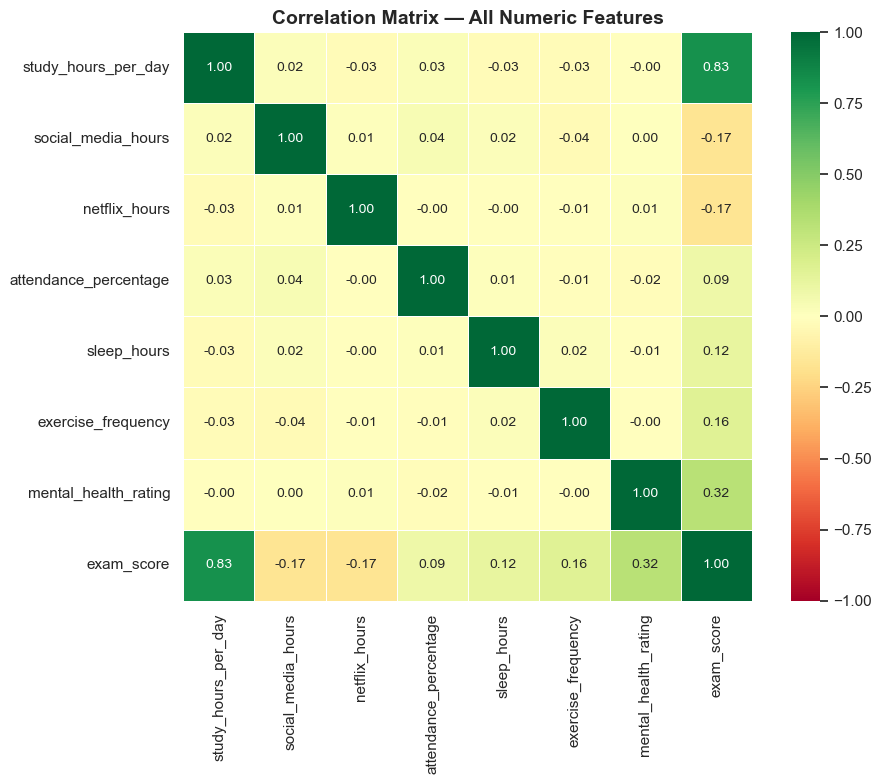

Correlation with exam_score (sorted):
exam_score               1.000
study_hours_per_day      0.825
mental_health_rating     0.322
exercise_frequency       0.160
sleep_hours              0.122
attendance_percentage    0.090
social_media_hours      -0.167
netflix_hours           -0.172
Name: exam_score, dtype: float64


In [41]:
# Correlation of numeric features with exam_score
numeric_df = df.select_dtypes(include=[np.number]).drop('age', axis=1)
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 10}, vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix — All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with exam_score
print("Correlation with exam_score (sorted):")
print(corr_matrix['exam_score'].sort_values(ascending=False).round(3))

---## Step 4: Data Cleaning & Preprocessing

In [42]:
# 4.1 Drop student_id (not a feature)
df = df.drop('student_id', axis=1)
print("Dropped student_id column.")
print("Shape after drop:", df.shape)

Dropped student_id column.
Shape after drop: (1000, 15)


In [43]:
# 4.2 Fill missing values in parental_education_level with mode
print("Missing before:", df['parental_education_level'].isnull().sum())
df['parental_education_level'] = df['parental_education_level'].fillna(
    df['parental_education_level'].mode()[0])
print("Missing after :", df['parental_education_level'].isnull().sum())

Missing before: 91
Missing after : 0


In [44]:
# 4.3 Encode categorical columns using Label Encoding
# LabelEncoder converts text categories to numbers
le = LabelEncoder()

categorical_cols = ['gender', 'part_time_job', 'diet_quality',
                    'parental_education_level', 'internet_quality',
                    'extracurricular_participation']

encoding_map = {}
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("Label Encoding mapping:")
for col, mapping in encoding_map.items():
    print(f"  {col}: {mapping}")

Label Encoding mapping:
  gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
  part_time_job: {'No': np.int64(0), 'Yes': np.int64(1)}
  diet_quality: {'Fair': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
  parental_education_level: {'Bachelor': np.int64(0), 'High School': np.int64(1), 'Master': np.int64(2)}
  internet_quality: {'Average': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
  extracurricular_participation: {'No': np.int64(0), 'Yes': np.int64(1)}


In [45]:
# 4.4 Final check — no missing values
print("Missing values after cleaning:", df.isnull().sum().sum())
print("Shape:", df.shape)
df.head()

Missing values after cleaning: 0
Shape: (1000, 15)


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,0,0.0,1.2,1.1,0,85.0,8.0,0,6,2,0,8,1,56.2
1,20,0,6.9,2.8,2.3,0,97.3,4.6,1,6,1,0,8,0,100.0
2,21,1,1.4,3.1,1.3,0,94.8,8.0,2,1,1,2,1,0,34.3
3,23,0,1.0,3.9,1.0,0,71.0,9.2,2,4,2,1,1,1,26.8
4,19,0,5.0,4.4,0.5,0,90.9,4.9,0,3,2,1,1,0,66.4


---## Step 5: Simple Linear Regression (SLR)### Using best single feature: study_hours_per_day

In [46]:
# Separate X (input) and y (target)
# SLR — only one feature (strongest correlation with exam_score)
X_slr = df[['study_hours_per_day']]
y     = df['exam_score']

print("X shape:", X_slr.shape)
print("y shape:", y.shape)

X shape: (1000, 1)
y shape: (1000,)


In [47]:
# Split data into Training (70%) and Testing (30%) sets
X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(
    X_slr, y, test_size=0.3, random_state=42)

print("Training samples:", len(X_train_slr))
print("Testing samples :", len(X_test_slr))

Training samples: 700
Testing samples : 300


In [48]:
# Create and train the Simple Linear Regression model
slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train_slr)

# Model parameters
print(f"Weight (Coefficient) : {slr_model.coef_[0]:.4f}")
print(f"Bias (Intercept)     : {slr_model.intercept_:.4f}")
print(f"\nFormula: Exam_Score = {slr_model.coef_[0]:.4f} x study_hours + ({slr_model.intercept_:.4f})")

Weight (Coefficient) : 9.5019
Bias (Intercept)     : 36.2293

Formula: Exam_Score = 9.5019 x study_hours + (36.2293)


In [49]:
# Predict on test data
y_pred_slr = slr_model.predict(X_test_slr)

# Model Evaluation — SLR
mae_slr  = mean_absolute_error(y_test_slr, y_pred_slr)
mse_slr  = mean_squared_error(y_test_slr, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr   = r2_score(y_test_slr, y_pred_slr)

print("===== Simple Linear Regression — Evaluation =====")
print(f"MAE  (Mean Absolute Error)      : {mae_slr:.4f}")
print(f"MSE  (Mean Squared Error)       : {mse_slr:.4f}")
print(f"RMSE (Root Mean Squared Error)  : {rmse_slr:.4f}")
print(f"R²   Score                      : {r2_slr:.4f}")

===== Simple Linear Regression — Evaluation =====
MAE  (Mean Absolute Error)      : 7.3746
MSE  (Mean Squared Error)       : 83.2919
RMSE (Root Mean Squared Error)  : 9.1264
R²   Score                      : 0.7001


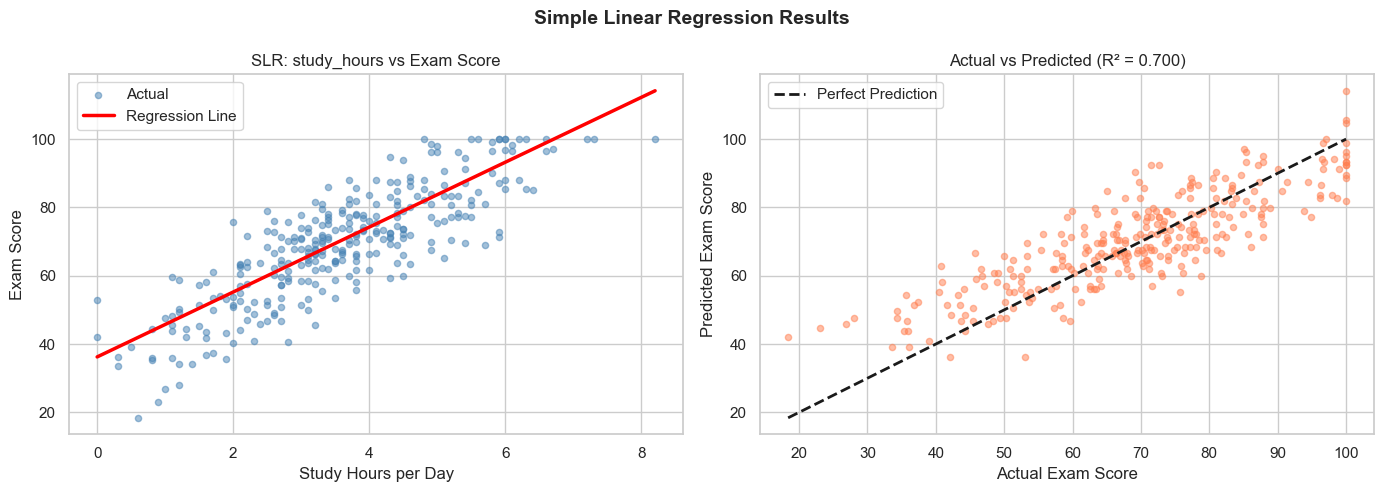

In [50]:
# Visualize SLR — Actual vs Predicted + Regression Line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter + regression line
axes[0].scatter(X_test_slr, y_test_slr, color='steelblue', alpha=0.5, s=20, label='Actual')
x_line = np.linspace(X_test_slr.min().values[0], X_test_slr.max().values[0], 100)
axes[0].plot(x_line, slr_model.predict(x_line.reshape(-1,1)),
             color='red', linewidth=2.5, label='Regression Line')
axes[0].set_title('SLR: study_hours vs Exam Score')
axes[0].set_xlabel('Study Hours per Day')
axes[0].set_ylabel('Exam Score')
axes[0].legend()

# Actual vs Predicted scatter
axes[1].scatter(y_test_slr, y_pred_slr, color='coral', alpha=0.5, s=20)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=2, label='Perfect Prediction')
axes[1].set_title(f'Actual vs Predicted (R² = {r2_slr:.3f})')
axes[1].set_xlabel('Actual Exam Score')
axes[1].set_ylabel('Predicted Exam Score')
axes[1].legend()

plt.suptitle('Simple Linear Regression Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---## Step 6: Multiple Linear Regression (MLR)### Using all numeric features

In [51]:
# MLR — use all features except target
X_mlr = df.drop('exam_score', axis=1)
y     = df['exam_score']

print("Features used:", X_mlr.columns.tolist())
print("X shape:", X_mlr.shape)
print("y shape:", y.shape)

Features used: ['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']
X shape: (1000, 14)
y shape: (1000,)


In [52]:
# Split data — same ratio and random state for fair comparison
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    X_mlr, y, test_size=0.3, random_state=42)

print("Training samples:", len(X_train_mlr))
print("Testing samples :", len(X_test_mlr))

Training samples: 700
Testing samples : 300


In [53]:
# Create and train Multiple Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X_train_mlr, y_train_mlr)

# Display learned coefficients (weights) for each feature
coef_df = pd.DataFrame({
    'Feature'    : X_mlr.columns,
    'Coefficient': mlr_model.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

print(f"Intercept (Bias): {mlr_model.intercept_:.4f}")
print("\nFeature Coefficients:")
print(coef_df.to_string(index=False))

Intercept (Bias): 6.1173

Feature Coefficients:
                      Feature  Coefficient
          study_hours_per_day       9.5765
                  sleep_hours       2.0260
         mental_health_rating       1.9457
           exercise_frequency       1.2836
                       gender       0.3180
        attendance_percentage       0.1455
                          age       0.0660
                part_time_job      -0.0144
extracurricular_participation      -0.0678
             internet_quality      -0.0823
     parental_education_level      -0.1516
                 diet_quality      -0.4384
                netflix_hours      -2.3722
           social_media_hours      -2.7372


In [54]:
# Predict on test data
y_pred_mlr = mlr_model.predict(X_test_mlr)

# Model Evaluation — MLR
mae_mlr  = mean_absolute_error(y_test_mlr, y_pred_mlr)
mse_mlr  = mean_squared_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr   = r2_score(y_test_mlr, y_pred_mlr)

print("===== Multiple Linear Regression — Evaluation =====")
print(f"MAE  (Mean Absolute Error)      : {mae_mlr:.4f}")
print(f"MSE  (Mean Squared Error)       : {mse_mlr:.4f}")
print(f"RMSE (Root Mean Squared Error)  : {rmse_mlr:.4f}")
print(f"R²   Score                      : {r2_mlr:.4f}")

===== Multiple Linear Regression — Evaluation =====
MAE  (Mean Absolute Error)      : 4.2415
MSE  (Mean Squared Error)       : 28.4094
RMSE (Root Mean Squared Error)  : 5.3300
R²   Score                      : 0.8977


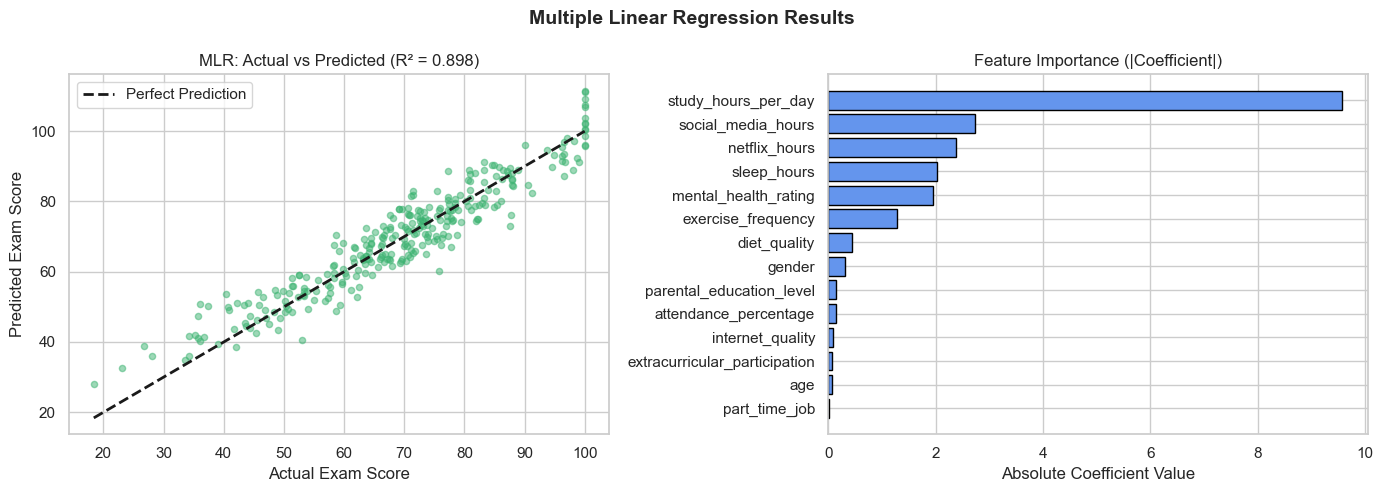

In [55]:
# Visualize MLR Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test_mlr, y_pred_mlr, color='mediumseagreen', alpha=0.5, s=20)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'MLR: Actual vs Predicted (R² = {r2_mlr:.3f})')
axes[0].set_xlabel('Actual Exam Score')
axes[0].set_ylabel('Predicted Exam Score')
axes[0].legend()

# Feature importance (absolute coefficients)
coef_df_sorted = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)
axes[1].barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'].abs(),
             color='cornflowerblue', edgecolor='black')
axes[1].set_title('Feature Importance (|Coefficient|)')
axes[1].set_xlabel('Absolute Coefficient Value')

plt.suptitle('Multiple Linear Regression Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

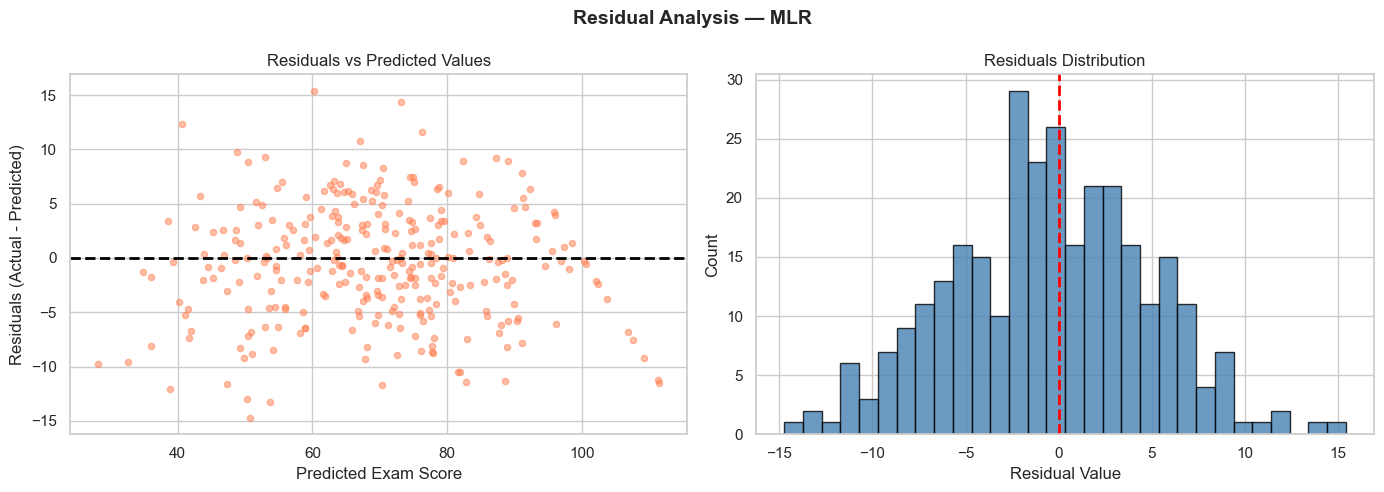

Mean of Residuals: -0.5377  (should be close to 0)


In [56]:
# Residuals plot — check if errors are random (good model sign)
residuals = y_test_mlr - y_pred_mlr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_mlr, residuals, color='coral', alpha=0.5, s=20)
axes[0].axhline(0, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Exam Score')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Count')

plt.suptitle('Residual Analysis — MLR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean of Residuals: {residuals.mean():.4f}  (should be close to 0)")

---## Step 7: SLR vs MLR — Model Comparison

  Metric  Simple LR (1 feature)  Multiple LR (all features)
     MAE                 7.3746                      4.2415
     MSE                83.2919                     28.4094
    RMSE                 9.1264                      5.3300
R² Score                 0.7001                      0.8977


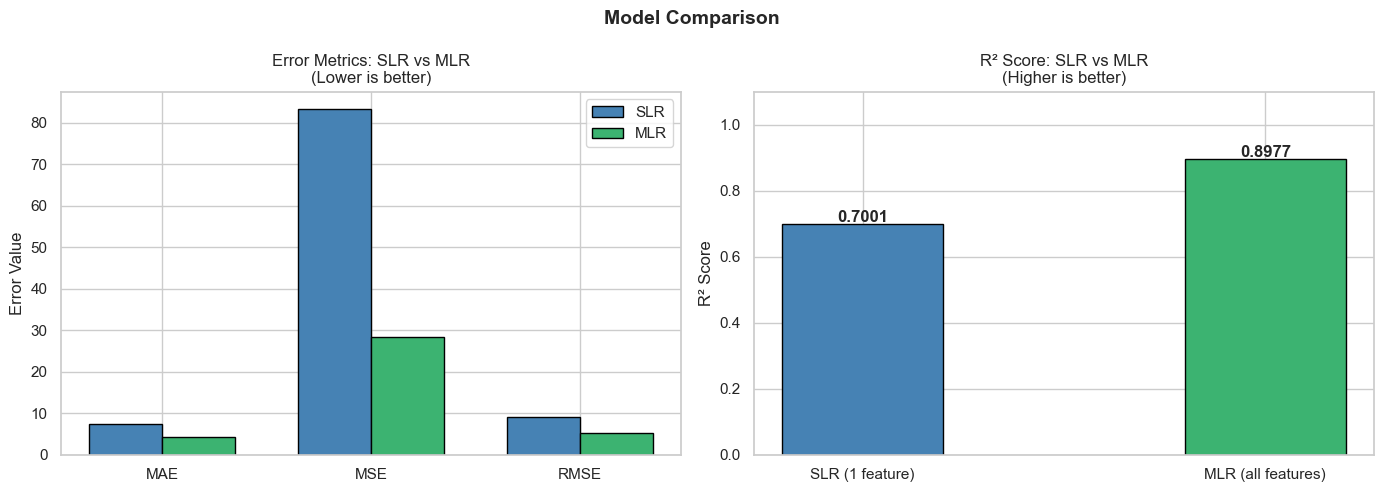


Conclusion: MLR is the better model with R² = 0.8977


In [57]:
# Side-by-side comparison table
comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Simple LR (1 feature)': [round(mae_slr,4), round(mse_slr,4),
                               round(rmse_slr,4), round(r2_slr,4)],
    'Multiple LR (all features)': [round(mae_mlr,4), round(mse_mlr,4),
                                    round(rmse_mlr,4), round(r2_mlr,4)]
})
print(comparison.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics  = ['MAE', 'MSE', 'RMSE']
slr_vals = [mae_slr, mse_slr, rmse_slr]
mlr_vals = [mae_mlr, mse_mlr, rmse_mlr]

x = range(len(metrics))
w = 0.35
axes[0].bar([i-w/2 for i in x], slr_vals, width=w, label='SLR', color='steelblue', edgecolor='black')
axes[0].bar([i+w/2 for i in x], mlr_vals, width=w, label='MLR', color='mediumseagreen', edgecolor='black')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(metrics)
axes[0].set_title('Error Metrics: SLR vs MLR\n(Lower is better)')
axes[0].set_ylabel('Error Value')
axes[0].legend()

axes[1].bar(['SLR (1 feature)', 'MLR (all features)'], [r2_slr, r2_mlr],
            color=['steelblue','mediumseagreen'], edgecolor='black', width=0.4)
for bar, v in zip(axes[1].patches, [r2_slr, r2_mlr]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.4f}',
                 ha='center', fontweight='bold')
axes[1].set_title('R² Score: SLR vs MLR\n(Higher is better)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.1)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

better = "MLR" if r2_mlr > r2_slr else "SLR"
print(f"\nConclusion: {better} is the better model with R² = {max(r2_slr, r2_mlr):.4f}")

---## Step 8: Prediction Results

In [58]:
# Show first 20 actual vs predicted values (MLR)
results_df = pd.DataFrame({
    'Actual_Exam_Score'   : y_test_mlr.values[:20],
    'Predicted_Exam_Score': y_pred_mlr[:20].round(2),
    'Error (Actual-Pred)' : (y_test_mlr.values[:20] - y_pred_mlr[:20]).round(2)
})
print("First 20 Prediction Results:")
print(results_df.to_string(index=False))

First 20 Prediction Results:
 Actual_Exam_Score  Predicted_Exam_Score  Error (Actual-Pred)
              64.2                 66.85                -2.65
              72.7                 75.19                -2.49
              79.0                 77.63                 1.37
              79.5                 74.21                 5.29
              58.2                 61.55                -3.35
              53.4                 54.53                -1.13
              70.8                 76.04                -5.24
              62.5                 55.52                 6.98
              36.8                 41.54                -4.74
              67.6                 72.78                -5.18
              53.0                 40.68                12.32
             100.0                102.37                -2.37
              58.4                 58.17                 0.23
              74.6                 72.34                 2.26
              28.0                 36.10 

In [59]:
# Predict for a new custom student
print("===== Predict Exam Score for a New Student =====\n")

# Create a new student record (all features in order)
new_student = pd.DataFrame({
    'age'                          : [20],
    'gender'                       : [1],     # 1 = Male (from encoding)
    'study_hours_per_day'          : [5.0],
    'social_media_hours'           : [2.0],
    'netflix_hours'                : [1.5],
    'part_time_job'                : [0],     # 0 = No
    'attendance_percentage'        : [85.0],
    'sleep_hours'                  : [7.0],
    'diet_quality'                 : [1],     # 1 = Good
    'exercise_frequency'           : [3],
    'parental_education_level'     : [0],     # 0 = Bachelor
    'internet_quality'             : [0],     # 0 = Average
    'mental_health_rating'         : [7],
    'extracurricular_participation': [1],     # 1 = Yes
})

predicted_score = mlr_model.predict(new_student)[0]
print(f"Student Profile:")
print(f"  Study Hours/Day    : 5.0 hrs")
print(f"  Attendance         : 85%")
print(f"  Sleep Hours        : 7 hrs")
print(f"  Mental Health Score: 7/10")
print(f"  Part-time Job      : No")
print(f"\nPredicted Exam Score: {predicted_score:.2f}")

===== Predict Exam Score for a New Student =====

Student Profile:
  Study Hours/Day    : 5.0 hrs
  Attendance         : 85%
  Sleep Hours        : 7 hrs
  Mental Health Score: 7/10
  Part-time Job      : No

Predicted Exam Score: 90.12


---## Step 9: Save & Load Model (joblib)

In [60]:
# Save both trained models to disk
joblib.dump(slr_model, 'slr_student_model.joblib')
joblib.dump(mlr_model, 'mlr_student_model.joblib')

print("Models saved successfully:")
print("  slr_student_model.joblib — Simple Linear Regression")
print("  mlr_student_model.joblib — Multiple Linear Regression")

Models saved successfully:
  slr_student_model.joblib — Simple Linear Regression
  mlr_student_model.joblib — Multiple Linear Regression


In [61]:
# Load and verify model works correctly
loaded_mlr = joblib.load('mlr_student_model.joblib')

# Verify with one test prediction
sample_pred = loaded_mlr.predict(X_test_mlr.iloc[:3])
print("Loaded model predictions (first 3 test samples):")
for i, (actual, pred) in enumerate(zip(y_test_mlr.values[:3], sample_pred)):
    print(f"  Sample {i+1}: Actual = {actual:.2f} | Predicted = {pred:.2f}")

print("\nModel loaded and working correctly!")

Loaded model predictions (first 3 test samples):
  Sample 1: Actual = 64.20 | Predicted = 66.85
  Sample 2: Actual = 72.70 | Predicted = 75.19
  Sample 3: Actual = 79.00 | Predicted = 77.63

Model loaded and working correctly!


---## Step 10: Summary & Business Insights

In [62]:
print("="*55)
print("    STUDENT PERFORMANCE PREDICTION — FINAL SUMMARY")
print("="*55)
print()
print("Dataset : 1000 students, 15 features, target = exam_score")
print()
print("── Simple Linear Regression (study_hours only) ──────────")
print(f"  MAE   : {mae_slr:.4f}")
print(f"  MSE   : {mse_slr:.4f}")
print(f"  RMSE  : {rmse_slr:.4f}")
print(f"  R²    : {r2_slr:.4f}")
print()
print("── Multiple Linear Regression (all 14 features) ─────────")
print(f"  MAE   : {mae_mlr:.4f}")
print(f"  MSE   : {mse_mlr:.4f}")
print(f"  RMSE  : {rmse_mlr:.4f}")
print(f"  R²    : {r2_mlr:.4f}")
print()
print("── Key Insights ─────────────────────────────────────────")
print("  1. study_hours_per_day is the strongest predictor")
print("     of exam_score (highest correlation)")
print("  2. attendance_percentage also strongly influences score")
print("  3. mental_health_rating positively impacts performance")
print("  4. social_media_hours and netflix_hours negatively")
print("     impact exam score")
print("  5. MLR outperforms SLR by using all available features")
print()
print("── Model Formula (MLR) ──────────────────────────────────")
print(f"  Exam_Score = (intercept: {mlr_model.intercept_:.2f})")
print("  + W1*age + W2*gender + W3*study_hours")
print("  + W4*social_media + W5*netflix + ... (14 features)")
print("="*55)

    STUDENT PERFORMANCE PREDICTION — FINAL SUMMARY

Dataset : 1000 students, 15 features, target = exam_score

── Simple Linear Regression (study_hours only) ──────────
  MAE   : 7.3746
  MSE   : 83.2919
  RMSE  : 9.1264
  R²    : 0.7001

── Multiple Linear Regression (all 14 features) ─────────
  MAE   : 4.2415
  MSE   : 28.4094
  RMSE  : 5.3300
  R²    : 0.8977

── Key Insights ─────────────────────────────────────────
  1. study_hours_per_day is the strongest predictor
     of exam_score (highest correlation)
  2. attendance_percentage also strongly influences score
  3. mental_health_rating positively impacts performance
  4. social_media_hours and netflix_hours negatively
     impact exam score
  5. MLR outperforms SLR by using all available features

── Model Formula (MLR) ──────────────────────────────────
  Exam_Score = (intercept: 6.12)
  + W1*age + W2*gender + W3*study_hours
  + W4*social_media + W5*netflix + ... (14 features)
